In [79]:
import pandas as pd

In [ ]:
male_country = df[df['Standardized_Gender'] == 'Male'][['Country', 'Standardized_Gender']]
female_country = df[df['Standardized_Gender'] == 'Female'][['Country', 'Standardized_Gender']]
male_country = male_country.value_counts()
female_country = female_country.value_counts()

male_country = pd.DataFrame(male_country).reset_index().rename(columns = {0: 'count'}).head(15)
female_country = pd.DataFrame(female_country).reset_index().rename(columns = {0: 'count'}).head(15)
male_country['count'] = male_country['count'] * -1
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows = 1, cols = 2,
                    specs = [[{}, {}]],
                    shared_yaxes = True,
                    horizontal_spacing = 0)

fig.append_trace(go.Bar(
    y = male_country.Country,
    x = male_country['count'],
    text = male_country['count'],
    textfont = dict(size = 10, color = '#6aa87b'),
    textposition = 'outside',
    name = 'Male responses',
    marker_color = '#6aa87b',
    orientation = 'h'),
    row = 1, col = 1)

fig.append_trace(go.Bar(
    y = male_country.Country,
    x = female_country['count'],
    text = female_country['count'],
    textfont = dict(size = 10, color = '#913f3f'),
    textposition = 'outside',
    name = 'Female responses',
    marker_color = '#913f3f',
    orientation = 'h'),
    row = 1, col = 2)

fig.update_xaxes(
    tickfont = dict(size = 15),
    tickmode = 'array',
    ticklen = 6,
    showline = False,
    showgrid = False,
    ticks = 'outside')

fig.update_yaxes(showgrid = False,
                 categoryorder = 'total ascending',
                 ticksuffix = ' ',
                 showline = False)

fig.update_layout(
    font_family = 'monospace',
    title = dict(text = 'Gender of the survey respondents across Countries', x = 0.525),
    margin = dict(t = 80, b = 0, l = 70, r = 40),
    hovermode = "y unified",
    plot_bgcolor = '#edf2c7',
    paper_bgcolor = '#edf2c7',
    font = dict(color = 'black'),
    legend = dict(orientation = "h",
                  yanchor = "bottom", y = 1,
                  xanchor = "center", x = 0.5),
    hoverlabel = dict(bgcolor = "#edf2c7", font_size = 13,
                      font_family = "Monospace"))

fig.show()

In [80]:
tgt_var = 'treatment'

df = pd.read_csv('data_clean.csv')
# Show the first few rows of the dataframe
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Standardized_Gender
0,2014-08-27 11:29:31,37,female,United States,IL,Uninformed,No,Yes,Often,6-25,...,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,Female
1,2014-08-27 11:29:37,44,m,United States,IN,Uninformed,No,No,Rarely,More than 1000,...,Maybe,No,No,No,No,No,Don't know,No,NaN,Male
2,2014-08-27 11:29:44,32,male,Canada,NaN,Uninformed,No,No,Rarely,6-25,...,No,No,Yes,Yes,Yes,Yes,No,No,NaN,Male
3,2014-08-27 11:29:46,31,male,United Kingdom,NaN,Uninformed,Yes,Yes,Often,26-100,...,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN,Male
4,2014-08-27 11:30:22,31,male,United States,TX,Uninformed,No,No,Never,100-500,...,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN,Male


In [348]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def create_barplot(ax, crosstab_melted, var_x, var_hue, features_map, plot_map):
    """Creates a barplot with normalized values."""
    # Normalize data
    crosstab_melted['Normalized'] = crosstab_melted.groupby(var_x)['Count'].transform(lambda x: x / x.sum())

    # Plot the barplot
    sns.barplot(
        data = crosstab_melted,
        x = var_x,
        y = 'Normalized',
        hue = var_hue,
        hue_order = features_map[var_hue]['order'],
        palette = features_map[var_hue]['palette'],
        ax = ax
        )

    # Apply plot map settings
    ax.set_title(
        plot_map['title_text'].format(var_x = features_map[var_x]['label'], var_hue = features_map[var_hue]['label']),
        fontsize = plot_map['title_fontsize'])
    ax.set_xlabel(features_map[var_x]['label'], fontsize = plot_map['label_fontsize'])
    ax.set_ylabel(plot_map['y_label_text'], fontsize = plot_map['label_fontsize'])

    # Customize tick font sizes
    ax.tick_params(axis = 'x', labelsize = plot_map['tick_fontsize'])
    ax.tick_params(axis = 'y', labelsize = plot_map['tick_fontsize'])

    # Customize legend font size
    ax.legend(title = features_map[var_hue]['label'], title_fontsize = plot_map['legend_fontsize'] + 4, fontsize = plot_map['legend_fontsize'])
    # legend.set_title(var_hue)  # Set legend title explicitly


def create_crosstab_barplot(df, var_x, var_hue, features_map, plot_map, filename = None):
    """
    Creates a cross-tabulation and plots barplots using two variables.
    """
    # Step 1: Create a crosstab and transform to long format
    crosstab = pd.crosstab(df[var_x], df[var_hue])
    crosstab_reset = crosstab.reset_index()
    crosstab_melted = pd.melt(crosstab_reset, id_vars = [var_x], var_name = var_hue, value_name = 'Count')

    # Step 2: Create the figure and axes
    fig, axs = plt.subplots(1, 2, figsize = (14, 6), sharey = True)

    # Step 3: Plot using create_barplot function
    create_barplot(axs[0], crosstab_melted, var_x, var_hue, features_map, plot_map)

    create_barplot(axs[1], crosstab_melted, var_hue, var_x, features_map, plot_map)

    # Save and show plot
    plt.tight_layout()
    
    if filename is not None: plt.savefig(filename, dpi=1200, bbox_inches='tight', transparent=True)
    
    plt.show()

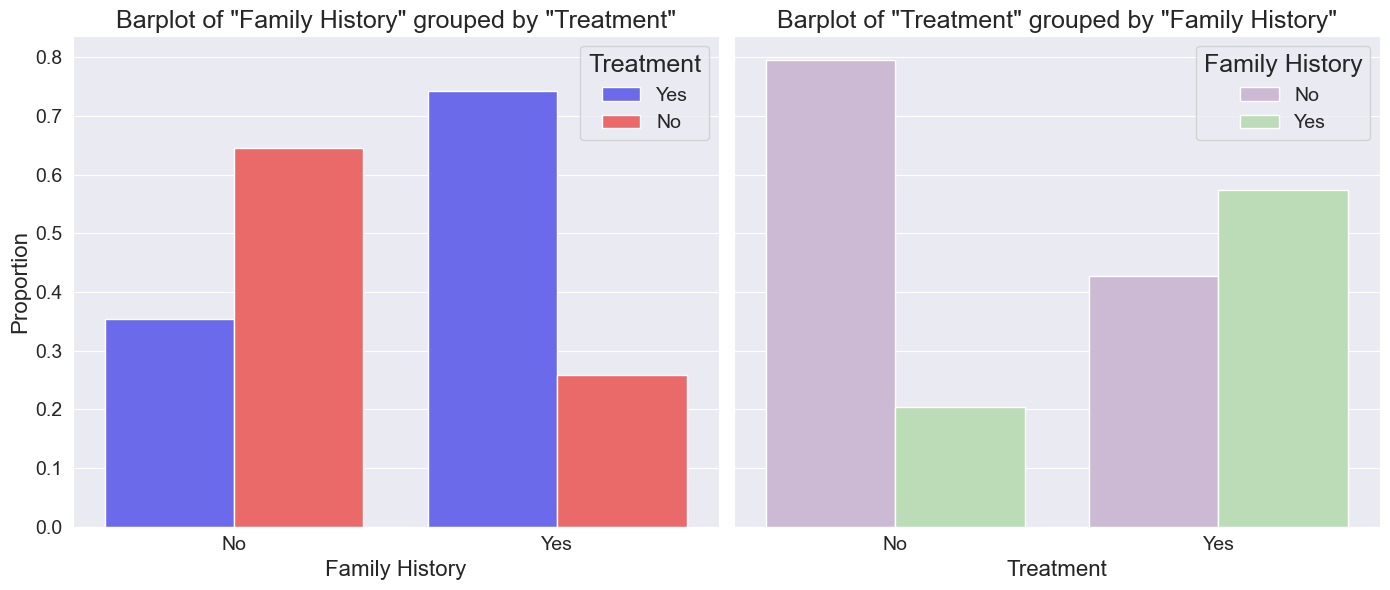

In [349]:
features_map = {'family_history': {'palette': 'PRGn',
                                   'order': ['No', 'Yes'],
                                   'label': 'Family History'},
                'treatment': {'palette': 'seismic',
                              'order': ['Yes', 'No'],
                              'label': 'Treatment'},
                'work_interfere': {'palette': 'bone',
                                   'order': ['Uninformed', 'Never', 'Rarely', 'Sometimes', 'Often'],
                                   'label': 'Work interferes'}
                }

# Sample plot settings
plot_map = {
    'title_text': 'Barplot of "{var_x}" grouped by "{var_hue}"',
    'x_label_text': None,
    'y_label_text': 'Proportion',
    'title_fontsize': 18,
    'label_fontsize': 16,
    'tick_fontsize': 14,
    'legend_fontsize': 14,
    }

create_crosstab_barplot(df = df, var_x = 'family_history', var_hue = 'treatment',
                        features_map = features_map, plot_map = plot_map,
                        filename = 'imgs/barplot_treat_history.png')

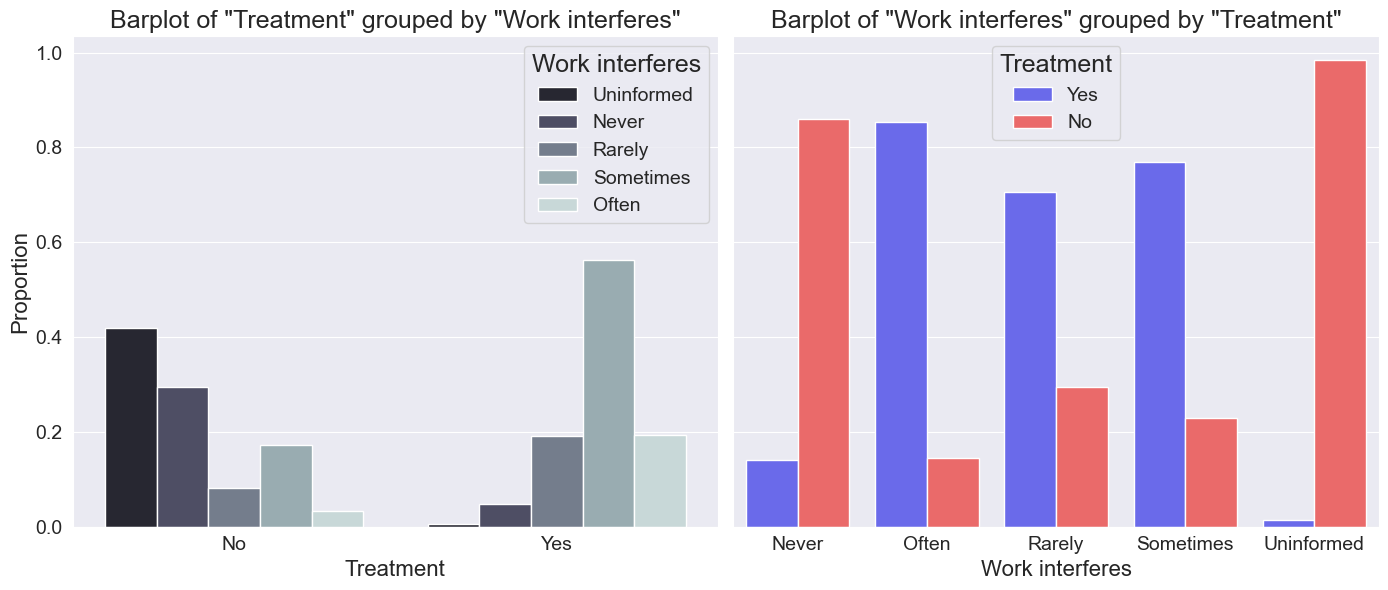

In [347]:
create_crosstab_barplot(df = df, var_x = 'treatment', var_hue = 'work_interfere',
                        features_map = features_map, plot_map = plot_map)

In [84]:
import pandas as pd
import plotly.express as px


def create_crosstab_sunburst(df, var1, var2):
    """
    Creates a cross-tabulation and plots a sunburst chart using the two variables.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame containing the two categorical variables.
        var1 (str): The name of the first variable (outer level).
        var2 (str): The name of the second variable (inner level).
        
    Returns:
        None: Displays the sunburst chart.
    """
    # Step 1: Create a crosstab between the two variables
    crosstab = pd.crosstab(df[var1], df[var2])

    # Step 2: Reset index and convert to long format (same as previous step)
    crosstab_reset = crosstab.reset_index()
    crosstab_melted = pd.melt(crosstab_reset, id_vars = [var1], var_name = var2, value_name = 'Count')

    # Step 3: Create the sunburst plot using Plotly Express
    fig = px.sunburst(
        crosstab_melted,
        path = [var1, var2],  # Define the hierarchy for the sunburst chart
        values = 'Count',  # The size of each segment will be determined by the 'Count'
        title = f'Sunburst of {var1} grouped by {var2}',
        )

    # Step 4: Show the plot
    fig.show()


# Example usage:
create_crosstab_sunburst(df, 'family_history', tgt_var)


In [350]:
import pandas as pd
import plotly.express as px
import numpy as np
import plotly.graph_objects as go


def create_dynamic_sunburst(df, features):
    """
    Creates a cross-tabulation and plots a sunburst chart using a dynamic number of features.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame containing the categorical variables.
        features (list): A list of variable names (column names) for the sunburst chart.
        
    Returns:
        None: Displays the sunburst chart.
    """
    # Check if the features list is empty
    if not features:
        print("No features provided for the sunburst chart.")
        return

    # Step 1: Create a crosstab between the features
    crosstab = df[features].value_counts().reset_index(name = 'Count')

    # Step 2: Create the sunburst plot using Plotly Express
    fig = px.sunburst(
        crosstab,
        path = features,  # Define the hierarchy for the sunburst chart
        values = 'Count',  # The size of each segment will be determined by the 'Count'
        title = 'Dynamic Sunburst Chart',
        )

    # Step 3: Show the plot
    fig.show()

# Example usage:
# Assuming df is your DataFrame with multiple categorical variables:
# create_dynamic_sunburst(df, ['Gender', 'Country', 'Age Group'])


In [26]:
# Example usage:
# Assuming df is your DataFrame with multiple categorical variables:
create_dynamic_sunburst(df, ['treatment', 'family_history', 'self_employed', ])

In [86]:
df

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Standardized_Gender
0,2014-08-27 11:29:31,37,female,United States,IL,Uninformed,No,Yes,Often,6-25,...,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,Female
1,2014-08-27 11:29:37,44,m,United States,IN,Uninformed,No,No,Rarely,More than 1000,...,Maybe,No,No,No,No,No,Don't know,No,NaN,Male
2,2014-08-27 11:29:44,32,male,Canada,NaN,Uninformed,No,No,Rarely,6-25,...,No,No,Yes,Yes,Yes,Yes,No,No,NaN,Male
3,2014-08-27 11:29:46,31,male,United Kingdom,NaN,Uninformed,Yes,Yes,Often,26-100,...,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN,Male
4,2014-08-27 11:30:22,31,male,United States,TX,Uninformed,No,No,Never,100-500,...,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,Uninformed,26-100,...,No,No,Some of them,Some of them,No,No,Don't know,No,NaN,Male
1255,2015-09-26 01:07:35,32,male,United States,IL,No,Yes,Yes,Often,26-100,...,No,No,Some of them,Yes,No,No,Yes,No,NaN,Male
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Yes,Yes,No,No,No,No,No,No,NaN,Male
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,Uninformed,100-500,...,Yes,No,No,No,No,No,No,No,NaN,Female


In [351]:
def generate_colors(num_colors, palette = 'tab20'):
    """Generate a list of distinct colors."""
    colors = plt.colormaps[palette](np.linspace(0, 1, num_colors))  # Use a colormap with distinct colors
    return [f'rgba({int(colors[i][0] * 255)}, {int(colors[i][1] * 255)}, {int(colors[i][2] * 255)}, 0.8)' for i in
            range(num_colors)]


def define_flow(df, color_dict, nodes, links = None):
    # TODO implement default link color case

    flow = df.copy().sort_values(by = links)

    flow['link_color'] = flow[links].apply(
        lambda x: color_dict.get(x, 'rgba(128, 128, 128, 0.8)'))  # Default to grey if not found
    flow['node_color'] = flow[nodes[0]].apply(lambda x: color_dict.get(x, 'rgba(128, 128, 128, 0.8)'))

    flow = flow.sort_values(by = links).drop(columns = links)
    flow.rename(columns = {nodes[0]: 'source', nodes[1]: 'target'}, inplace = True)

    return flow  #[['source', 'target', 'Count', 'link_color', 'node_color']]


def plot_sankley(df, features_map):
    features = list(features_map.keys())
    crosstab = df[features].copy()

    # Create unique labels by combining column names and their values
    for feature in features:
        crosstab[feature] = crosstab[feature].astype(str)  # Ensure all values are string for concatenation
        crosstab[feature] = feature + '__' + crosstab[feature]  # Append column name to each value

    crosstab = crosstab[features].value_counts().reset_index(name = 'Count')

    dict_nodes = {}
    unique_nodes = []
    for feature, params in features_map.items():
        # TODO improve this pseudologic
        cat_order = [feature + '__' + v for v in params['order']]
        unique_nodes += cat_order
        cat_type = pd.CategoricalDtype(categories = cat_order, ordered = True)
        crosstab[feature] = crosstab[feature].astype(cat_type)
        crosstab = crosstab.sort_values(feature)
        feat_vals = crosstab[feature].unique().tolist()

        node_col = generate_colors(num_colors = len(feat_vals), palette = params['palette'])

        for label, color in zip(feat_vals, node_col):
            dict_nodes[label] = color

    # TODO implement logic to handle the flow definition automatically 
    cross_A = define_flow(crosstab, dict_nodes, [features[0], features[1]], links = features[2])
    cross_B = define_flow(crosstab, dict_nodes, [features[1], features[2]], links = features[0])

    df_cross = pd.concat([cross_A, cross_B], axis = 0)
    df_cross.head()
    # unique_nodes = pd.Series(df_cross[['source', 'target']].values.ravel()).unique()
    node_indices = {node: index for index, node in enumerate(unique_nodes)}
    color_nodes = [dict_nodes[n].replace('.8)', '1)') for n in unique_nodes]

    # Create the source-target format
    df_cross['Source'] = df_cross['source'].map(node_indices)
    df_cross['Target'] = df_cross['target'].map(node_indices)
    # df_cross['link_color'] = df_cross['link_color'].str.replace('.8)', '.5)')

    fig = go.Figure(go.Sankey(
        node = dict(
            pad = 15,
            thickness = 20,
            line = dict(color = "black", width = 0.5),
            label = unique_nodes,
            color = color_nodes
            ),
        link = dict(
            source = df_cross['Source'],  # Source nodes
            target = df_cross['Target'],  # Target nodes
            value = df_cross['Count'],  # Flow values
            color = df_cross['link_color']
            )
        ))

    fig.update_layout(
        # title_text = "Sankey Diagram",
        # font_size = 10,
        paper_bgcolor = 'rgba(0,0,0,0)',  # Background of the entire figure
        plot_bgcolor = 'rgba(0,0,0,0)'  # Background of the plotting area
        )
    fig.show()

    df_agg = df_cross[['Source', 'Target', 'node_color', 'Count']]
    df_agg = df_agg.groupby(df_agg.columns[:-1].tolist()).sum().reset_index()
    fig = go.Figure(go.Sankey(
        node = dict(
            pad = 15,
            thickness = 20,
            line = dict(color = "black", width = 0.5),
            label = unique_nodes,
            color = color_nodes
            ),
        link = dict(
            source = df_agg['Source'],  # Source nodes
            target = df_agg['Target'],  # Target nodes
            value = df_agg['Count'],  # Flow values
            color = df_agg['node_color']
            )
        ))

    fig.update_layout(
        # title_text = "Sankey Diagram",
        # font_size = 10,
        paper_bgcolor = 'rgba(0,0,0,0)',  # Background of the entire figure
        plot_bgcolor = 'rgba(0,0,0,0)'  # Background of the plotting area
        )
    fig.show()

    return df_cross

In [352]:
cross = plot_sankley(df = df,
                     features_map = {'family_history': {'palette': 'PRGn',
                                                        'order': ['Yes', 'No']},
                                     'treatment': {'palette': 'seismic',
                                                   'order': ['Yes', 'No']},
                                     'work_interfere': {'palette': 'Reds',
                                                        'order': ['Uninformed', 'Never', 'Rarely', 'Sometimes',
                                                                  'Often']}
                                     })

In [236]:
cross

,source,target,Count,link_color,node_color,Source,Target
19,family_history__Yes,treatment__Yes,1,"rgba(255, 245, 240, 0.8)","rgba(64, 0, 75, 0.8)",0,2
10,family_history__Yes,treatment__No,42,"rgba(255, 245, 240, 0.8)","rgba(64, 0, 75, 0.8)",0,3
0,family_history__No,treatment__No,218,"rgba(255, 245, 240, 0.8)","rgba(0, 68, 27, 0.8)",1,3
18,family_history__No,treatment__Yes,3,"rgba(255, 245, 240, 0.8)","rgba(0, 68, 27, 0.8)",1,2
12,family_history__Yes,treatment__No,27,"rgba(252, 186, 160, 0.8)","rgba(64, 0, 75, 0.8)",0,3
2,family_history__No,treatment__No,156,"rgba(252, 186, 160, 0.8)","rgba(0, 68, 27, 0.8)",1,3
13,family_history__No,treatment__Yes,19,"rgba(252, 186, 160, 0.8)","rgba(0, 68, 27, 0.8)",1,2
15,family_history__Yes,treatment__Yes,11,"rgba(252, 186, 160, 0.8)","rgba(64, 0, 75, 0.8)",0,2
8,family_history__No,treatment__Yes,50,"rgba(250, 105, 73, 0.8)","rgba(0, 68, 27, 0.8)",1,2
4,family_history__Yes,treatment__Yes,72,"rgba(250, 105, 73, 0.8)","rgba(64, 0, 75, 0.8)",0,2


In [181]:
feat_vals

[nan]

In [184]:
cat_order

['work_interfere__Uninformed',
 'work_interfere__Never',
 'work_interfere__Rarely',
 'work_interfere__Sometimes',
 'work_interfere__Often']

In [185]:
crosstab

,family_history,treatment,work_interfere,Count
2,NaN,NaN,NaN,156
14,NaN,NaN,NaN,13
9,NaN,NaN,NaN,42
6,NaN,NaN,NaN,66
0,NaN,NaN,NaN,218
13,NaN,NaN,NaN,19
7,NaN,NaN,NaN,51
8,NaN,NaN,NaN,50
3,NaN,NaN,NaN,149
18,NaN,NaN,NaN,3


In [192]:
desired_order = ["cherry", "banana", "apple", "date", "elderberry"]
cat_type = pd.CategoricalDtype(categories = desired_order, ordered = True)

In [211]:
features = ['family_history', 'treatment', 'work_interfere']

crosstab = df[features].copy()

# Create unique labels by combining column names and their values
for feature in features:
    crosstab[feature] = crosstab[feature].astype(str)  # Ensure all values are string for concatenation
    crosstab[feature] = feature + '__' + crosstab[feature]  # Append column name to each value

crosstab = crosstab[features].value_counts().reset_index(name = 'Count').sort_values(by = features)
crosstab

,family_history,treatment,work_interfere,Count
2,family_history__No,treatment__No,work_interfere__Never,156
14,family_history__No,treatment__No,work_interfere__Often,13
9,family_history__No,treatment__No,work_interfere__Rarely,42
6,family_history__No,treatment__No,work_interfere__Sometimes,66
0,family_history__No,treatment__No,work_interfere__Uninformed,218
13,family_history__No,treatment__Yes,work_interfere__Never,19
7,family_history__No,treatment__Yes,work_interfere__Often,51
8,family_history__No,treatment__Yes,work_interfere__Rarely,50
3,family_history__No,treatment__Yes,work_interfere__Sometimes,149
18,family_history__No,treatment__Yes,work_interfere__Uninformed,3


In [212]:
# crosstab['fam'] = 'family_history_' +  crosstab['family_history'].str.replace('family_history', '').str.replace('_', '')
# crosstab['trat'] = 'treatment_' +  crosstab['treatment'].str.replace('treatment', '').str.replace('_', '')
# crosstab['w_inter'] = 'work_interfere_' +  crosstab['work_interfere'].str.replace('work_interfere', '').str.replace('_', '')
# 
# crosstab = crosstab.sort_values(by = features).drop(columns = features)
# crosstab

In [213]:
unique_labels = np.sort(pd.unique(crosstab.iloc[:, :-1].values.ravel()))


def generate_colors(num_colors):
    """Generate a list of distinct colors."""
    colors = plt.colormaps['tab20'](np.linspace(0, 1, num_colors))  # Use a colormap with distinct colors
    return [f'rgba({int(colors[i][0] * 255)}, {int(colors[i][1] * 255)}, {int(colors[i][2] * 255)}, 0.8)' for i in
            range(num_colors)]


# Generate distinct colors for nodes
node_colors = generate_colors(len(unique_labels))

dict_nodes = {}
for label, color in zip(unique_labels, node_colors):
    dict_nodes[label] = color

dict_nodes

{'family_history__No': 'rgba(31, 119, 180, 0.8)',
 'family_history__Yes': 'rgba(255, 127, 14, 0.8)',
 'treatment__No': 'rgba(152, 223, 138, 0.8)',
 'treatment__Yes': 'rgba(255, 152, 150, 0.8)',
 'work_interfere__Never': 'rgba(140, 86, 75, 0.8)',
 'work_interfere__Often': 'rgba(227, 119, 194, 0.8)',
 'work_interfere__Rarely': 'rgba(199, 199, 199, 0.8)',
 'work_interfere__Sometimes': 'rgba(219, 219, 141, 0.8)',
 'work_interfere__Uninformed': 'rgba(158, 218, 229, 0.8)'}

In [214]:
def define_flow(df, color_dict, nodes, links = None):
    # TODO implement default link color case

    flow = df.copy().sort_values(by = links)

    flow['link_color'] = flow[links].apply(
        lambda x: color_dict.get(x, 'rgba(128, 128, 128, 0.8)'))  # Default to grey if not found
    flow['node_color'] = flow[nodes[0]].apply(lambda x: color_dict.get(x, 'rgba(128, 128, 128, 0.8)'))

    flow = flow.sort_values(by = links).drop(columns = links)
    flow.rename(columns = {nodes[0]: 'source', nodes[1]: 'target'}, inplace = True)

    return flow  #[['source', 'target', 'Count', 'link_color', 'node_color']]

In [215]:
cross_A = define_flow(crosstab, dict_nodes, ['family_history', 'treatment'], links = 'work_interfere')
cross_B = define_flow(crosstab, dict_nodes, ['treatment', 'work_interfere'], links = 'family_history')

df_cross = pd.concat([cross_A, cross_B], axis = 0)
df_cross.head()

,source,target,Count,link_color,node_color
2,family_history__No,treatment__No,156,"rgba(140, 86, 75, 0.8)","rgba(31, 119, 180, 0.8)"
13,family_history__No,treatment__Yes,19,"rgba(140, 86, 75, 0.8)","rgba(31, 119, 180, 0.8)"
12,family_history__Yes,treatment__No,27,"rgba(140, 86, 75, 0.8)","rgba(255, 127, 14, 0.8)"
15,family_history__Yes,treatment__Yes,11,"rgba(140, 86, 75, 0.8)","rgba(255, 127, 14, 0.8)"
14,family_history__No,treatment__No,13,"rgba(227, 119, 194, 0.8)","rgba(31, 119, 180, 0.8)"


In [218]:
unique_nodes = pd.Series(df_cross[['source', 'target']].values.ravel()).unique()
node_indices = {node: index for index, node in enumerate(unique_nodes)}
color_nodes = [dict_nodes[n] for n in unique_nodes]

# Create the source-target format
df_cross['Source'] = df_cross['source'].map(node_indices)
df_cross['Target'] = df_cross['target'].map(node_indices)

In [225]:
df_cross

,source,target,Count,link_color,node_color,Source,Target
2,family_history__No,treatment__No,156,"rgba(140, 86, 75, 0.8)","rgba(31, 119, 180, 0.8)",1,3
13,family_history__No,treatment__Yes,19,"rgba(140, 86, 75, 0.8)","rgba(31, 119, 180, 0.8)",1,2
12,family_history__Yes,treatment__No,27,"rgba(140, 86, 75, 0.8)","rgba(255, 127, 14, 0.8)",0,3
15,family_history__Yes,treatment__Yes,11,"rgba(140, 86, 75, 0.8)","rgba(255, 127, 14, 0.8)",0,2
14,family_history__No,treatment__No,13,"rgba(227, 119, 194, 0.8)","rgba(31, 119, 180, 0.8)",1,3
7,family_history__No,treatment__Yes,51,"rgba(227, 119, 194, 0.8)","rgba(31, 119, 180, 0.8)",1,2
17,family_history__Yes,treatment__No,8,"rgba(227, 119, 194, 0.8)","rgba(255, 127, 14, 0.8)",0,3
5,family_history__Yes,treatment__Yes,72,"rgba(227, 119, 194, 0.8)","rgba(255, 127, 14, 0.8)",0,2
16,family_history__Yes,treatment__No,9,"rgba(199, 199, 199, 0.8)","rgba(255, 127, 14, 0.8)",0,3
8,family_history__No,treatment__Yes,50,"rgba(199, 199, 199, 0.8)","rgba(31, 119, 180, 0.8)",1,2


In [229]:
fig = go.Figure(go.Sankey(
    node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = unique_nodes,
        color = color_nodes
        ),
    link = dict(
        source = df_cross['Source'],  # Source nodes
        target = df_cross['Target'],  # Target nodes
        value = df_cross['Count'],  # Flow values
        color = df_cross['link_color']
        )
    ))

fig.update_layout(title_text = "Sankey Diagram", font_size = 10)
fig.show()

In [222]:
df_cross.sort_values(['Source', 'Target'])

,source,target,Count,link_color,node_color,Source,Target
15,family_history__Yes,treatment__Yes,11,"rgba(140, 86, 75, 0.8)","rgba(255, 127, 14, 0.8)",0,2
5,family_history__Yes,treatment__Yes,72,"rgba(227, 119, 194, 0.8)","rgba(255, 127, 14, 0.8)",0,2
4,family_history__Yes,treatment__Yes,72,"rgba(199, 199, 199, 0.8)","rgba(255, 127, 14, 0.8)",0,2
1,family_history__Yes,treatment__Yes,209,"rgba(219, 219, 141, 0.8)","rgba(255, 127, 14, 0.8)",0,2
19,family_history__Yes,treatment__Yes,1,"rgba(158, 218, 229, 0.8)","rgba(255, 127, 14, 0.8)",0,2
12,family_history__Yes,treatment__No,27,"rgba(140, 86, 75, 0.8)","rgba(255, 127, 14, 0.8)",0,3
17,family_history__Yes,treatment__No,8,"rgba(227, 119, 194, 0.8)","rgba(255, 127, 14, 0.8)",0,3
16,family_history__Yes,treatment__No,9,"rgba(199, 199, 199, 0.8)","rgba(255, 127, 14, 0.8)",0,3
11,family_history__Yes,treatment__No,41,"rgba(219, 219, 141, 0.8)","rgba(255, 127, 14, 0.8)",0,3
10,family_history__Yes,treatment__No,42,"rgba(158, 218, 229, 0.8)","rgba(255, 127, 14, 0.8)",0,3


In [163]:
fig = go.Figure(go.Sankey(
    node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = unique_nodes,
        color = color_nodes
        ),
    link = dict(
        source = df_cross['Source'],  # Source nodes
        target = df_cross['Target'],  # Target nodes
        value = df_cross['Count'],  # Flow values
        color = df_cross['node_color']
        )
    ))

fig.update_layout(title_text = "Sankey Diagram", font_size = 10)
fig.show()

In [134]:
df_agg = df_cross[['Source', 'Target', 'node_color', 'Count']]
df_agg = df_agg.groupby(df_agg.columns[:-1].tolist()).sum().reset_index()

In [135]:
fig = go.Figure(go.Sankey(
    node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = unique_nodes,
        color = color_nodes
        ),
    link = dict(
        source = df_agg['Source'],  # Source nodes
        target = df_agg['Target'],  # Target nodes
        value = df_agg['Count'],  # Flow values
        color = df_agg['node_color']
        )
    ))

fig.update_layout(title_text = "Sankey Diagram", font_size = 10)
fig.show()

In [16]:
import pandas as pd
import plotly.graph_objects as go


def create_dynamic_sankey(df, features):
    """
    Creates a cross-tabulation and plots a Sankey chart using a dynamic number of features,
    with unique labels for duplicated values in different columns.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame containing the categorical variables.
        features (list): A list of variable names (column names) for the Sankey chart.
        
    Returns:
        None: Displays the Sankey chart.
    """
    # Check if the features list is empty
    if not features:
        print("No features provided for the Sankey chart.")
        return

    # Step 1: Create a crosstab between the features
    # Create unique labels by combining column names and their values
    for feature in features:
        df[feature] = df[feature].astype(str)  # Ensure all values are string for concatenation
        df[feature] = feature + '_' + df[feature]  # Append column name to each value

    crosstab = df[features].value_counts().reset_index(name = 'Count')

    # Step 2: Prepare data for the Sankey diagram
    # Create a mapping from unique categories to indices
    unique_labels = pd.concat([crosstab[feature] for feature in features]).unique()
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}

    # Define source, target, and values for the Sankey diagram
    sources = []
    targets = []
    values = []

    for _, row in crosstab.iterrows():
        # For each row, create a flow from each feature to the next
        for i in range(len(features) - 1):
            source = label_to_index[row[i]]
            target = label_to_index[row[i + 1]]
            sources.append(source)
            targets.append(target)
            values.append(row['Count'])

    # Step 3: Create the Sankey diagram
    fig = go.Figure(data = [go.Sankey(
        node = dict(
            pad = 15,
            thickness = 20,
            line = dict(color = "black", width = 0.5),
            label = unique_labels,
            color = 'blue'
            ),
        link = dict(
            source = sources,
            target = targets,
            value = values
            ))])

    # Add title
    fig.update_layout(title_text = 'Dynamic Sankey Chart', font_size = 10)

    # Step 4: Show the plot
    fig.show()


# Example usage:
# Assuming df is your DataFrame with multiple categorical variables:
# create_dynamic_sankey(df, ['Gender', 'Country', 'Treatment'])

# Example usage:
# Assuming df is your DataFrame with multiple categorical variables:
# create_dynamic_sankey(df, ['Gender', 'Country', 'Treatment'])
create_dynamic_sankey(df, ['family_history', 'treatment', 'work_interfere', ])

KeyError: 'family_history'

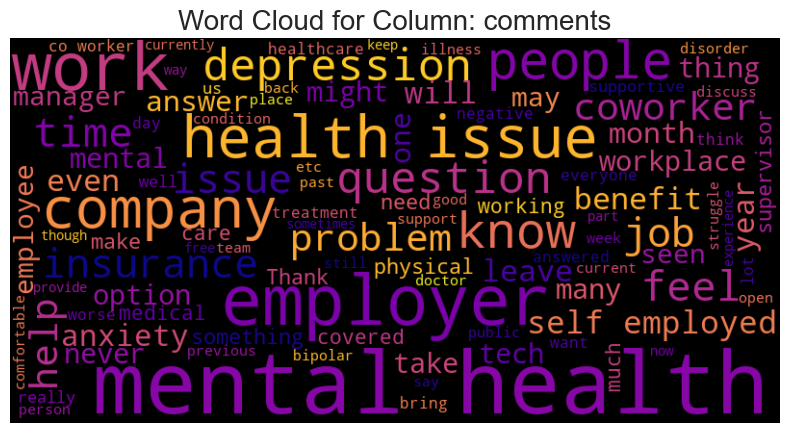

In [20]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud


def plot_word_cloud_from_column(df, column_name, max_words = 200, background_color = 'white', colormap = 'viridis',
                                width = 800, height = 400):
    """
    Generates and plots a word cloud from a specified column of a DataFrame.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame containing the text data.
        column_name (str): The name of the column from which to generate the word cloud.
        max_words (int): Maximum number of words to display in the word cloud.
        background_color (str): Background color of the word cloud (e.g., 'white', 'black').
        colormap (str): Color map to use for the words (e.g., 'viridis', 'plasma').
        width (int): Width of the word cloud image.
        height (int): Height of the word cloud image.
        
    Returns:
        None: Displays the word cloud.
    """

    # Combine all text from the specified column into a single string
    text = ' '.join(df[column_name].dropna().astype(str))  # Convert to string and drop NaN values

    # Create the word cloud object with the specified parameters
    wordcloud = WordCloud(
        max_words = max_words,
        background_color = background_color,
        colormap = colormap,
        width = width,
        height = height
        ).generate(text)

    # Plot the word cloud using matplotlib
    plt.figure(figsize = (10, 5))
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis('off')  # Hide the axis
    plt.title(f'Word Cloud for Column: {column_name}', fontsize = 20)
    plt.show()


# Example usage:
# Assuming you have a DataFrame 'df' with a column 'text_column':
plot_word_cloud_from_column(df, 'comments', max_words = 100, background_color = 'black', colormap = 'plasma')


## tratamento genero

In [94]:
import arff
import pandas as pd

# Load the ARFF file
with open('dataset_') as f:
    dataset = arff.load(f)

# Convert to a Pandas DataFrame
df = pd.DataFrame(dataset['data'], columns = [attr[0] for attr in dataset['attributes']])
df = df[(df['Age'] >= 18) & (df['Age'] < 100)]

tgt_vat = 'treatment'
# Show the first few rows of the dataframe
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,None,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,None
1,2014-08-27 11:29:37,44,M,United States,IN,None,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,None
2,2014-08-27 11:29:44,32,Male,Canada,None,None,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,None
3,2014-08-27 11:29:46,31,Male,United Kingdom,None,None,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,None
4,2014-08-27 11:30:22,31,Male,United States,TX,None,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,None


In [95]:
df['Gender'] = df['Gender'].str.replace('ake', 'ale')
df['Gender'] = df['Gender'].str.lower().str.strip()

In [96]:
import pandas as pd
import numpy as np


# Function to map gender entries
def map_gender(gender):
    gender_lower = str(gender).lower()

    # Mapping for Female
    female_keywords = ['female', 'f', 'woman', 'cis female', 'femail', 'woman', 'femake', 'cis-female',
                       'cis-female/femme', 'trans woman', 'trans-female', 'female (cis)', 'female (trans)']
    if any(keyword in gender_lower for keyword in female_keywords):
        return 'Female'

    # Mapping for Male
    male_keywords = ['male', 'm', 'man', 'cis male', 'male-ish', 'mail', 'mal', 'maile', 'msle',
                     'male leaning androgynous', 'something kinda male?']
    if any(keyword in gender_lower for keyword in male_keywords):
        return 'Male'

    # If not Male or Female, categorize as Other
    return 'Other'


# Apply the mapping function to the 'Gender' column
df['Standardized_Gender'] = df['Gender'].apply(map_gender)

df


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Standardized_Gender
0,2014-08-27 11:29:31,37,female,United States,IL,None,No,Yes,Often,6-25,...,No,No,Some of them,Yes,No,Maybe,Yes,No,None,Female
1,2014-08-27 11:29:37,44,m,United States,IN,None,No,No,Rarely,More than 1000,...,Maybe,No,No,No,No,No,Don't know,No,None,Male
2,2014-08-27 11:29:44,32,male,Canada,None,None,No,No,Rarely,6-25,...,No,No,Yes,Yes,Yes,Yes,No,No,None,Male
3,2014-08-27 11:29:46,31,male,United Kingdom,None,None,Yes,Yes,Often,26-100,...,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,None,Male
4,2014-08-27 11:30:22,31,male,United States,TX,None,No,No,Never,100-500,...,No,No,Some of them,Yes,Yes,Yes,Don't know,No,None,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,None,No,No,Yes,None,26-100,...,No,No,Some of them,Some of them,No,No,Don't know,No,None,Male
1255,2015-09-26 01:07:35,32,male,United States,IL,No,Yes,Yes,Often,26-100,...,No,No,Some of them,Yes,No,No,Yes,No,None,Male
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Yes,Yes,No,No,No,No,No,No,None,Male
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,None,100-500,...,Yes,No,No,No,No,No,No,No,None,Female


In [97]:
df[['Gender', 'Standardized_Gender', 'Age']].groupby(['Standardized_Gender', 'Gender']).count()

Age
Standardized_Gender Gender                                             
Female              cis female                                        1
                    cis-female/femme                                  1
                    f                                                53
                    femail                                            1
                    female                                          186
                    female (cis)                                      1
                    female (trans)                                    2
                    fluid                                             1
                    trans woman                                       1
                    trans-female                                      1
                    woman                                             4
Male                cis male                                          3
                    cis man                                           1
                    m                                               150
                    mail                                              1
                    maile                                             1
                    mal                                               1
                    male                                            823
                    male (cis)                                        1
                    male leaning androgynous                          1
                    male-ish                                          1
                    malr                                              1
                    man                                               2
                    msle                                              1
                    ostensibly male, unsure what that really means    1
                    something kinda male?                             1
Other               agender                                           1
                    androgyne                                         1
                    enby                                              1
                    genderqueer                                       1
                    guy (-ish) _                                      1
                    nah                                               1
                    neuter                                            1
                    non-binary                                        1
                    queer                                             1
                    queer/she/they                                    1

In [98]:
df.isna().sum()[df.isna().sum() > 0]

state              513
self_employed       18
work_interfere     262
comments          1090
dtype: int64

In [99]:
df['self_employed'] = df['self_employed'].fillna('Uninformed')
df['work_interfere'] = df['work_interfere'].fillna('Uninformed')

In [100]:
for c in df.drop(columns = ['Timestamp', 'comments', 'obs_consequence', 'Gender', 'Age', 'Country', 'state']).columns:
    print(c, len(df[c].unique()), list((df[c].unique())))

self_employed 3 ['Uninformed', 'Yes', 'No']
family_history 2 ['No', 'Yes']
treatment 2 ['Yes', 'No']
work_interfere 5 ['Often', 'Rarely', 'Never', 'Sometimes', 'Uninformed']
no_employees 6 ['6-25', 'More than 1000', '26-100', '100-500', '1-5', '500-1000']
remote_work 2 ['No', 'Yes']
tech_company 2 ['Yes', 'No']
benefits 3 ['Yes', "Don't know", 'No']
care_options 3 ['Not sure', 'No', 'Yes']
wellness_program 3 ['No', "Don't know", 'Yes']
seek_help 3 ['Yes', "Don't know", 'No']
anonymity 3 ['Yes', "Don't know", 'No']
leave 5 ['Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult', 'Very easy']
mental_health_consequence 3 ['No', 'Maybe', 'Yes']
phys_health_consequence 3 ['No', 'Yes', 'Maybe']
coworkers 3 ['Some of them', 'No', 'Yes']
supervisor 3 ['Yes', 'No', 'Some of them']
mental_health_interview 3 ['No', 'Yes', 'Maybe']
phys_health_interview 3 ['Maybe', 'No', 'Yes']
mental_vs_physical 3 ['Yes', "Don't know", 'No']
Standardized_Gender 3 ['Female', 'Male', 'Other']


In [107]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ['Not sure', 'No', 'Yes'] -> categorica
# ['Yes', "Don't know", 'No'] -> categorica
# ['No', 'Maybe', 'Yes'] -> ordinal
# ['Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult', 'Very easy'] -> ordinal


# Define categorical and ordinal columns
nominal_cols = [
    'Standardized_Gender',
    'self_employed',
    'family_history',
    'treatment',
    'remote_work',
    'tech_company',
    'benefits',
    'care_options',
    'wellness_program',
    'seek_help',
    'anonymity',
    'mental_vs_physical',
    ]

# Define ordinal columns with the corresponding order
ordinal_cols = {
    'work_interfere': ['Uninformed', 'Never', 'Rarely', 'Sometimes', 'Often'],
    'no_employees': ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000', ],
    'leave': ['Very difficult', 'Somewhat difficult', 'Somewhat easy', "Don't know", 'Very easy'],
    'mental_health_consequence': ['No', 'Maybe', 'Yes'],
    'phys_health_consequence': ['No', 'Maybe', 'Yes'],
    'coworkers': ['No', 'Some of them', 'Yes'],
    'supervisor': ['No', 'Some of them', 'Yes'],
    'mental_health_interview': ['No', 'Maybe', 'Yes'],
    'phys_health_interview': ['No', 'Maybe', 'Yes']
    }


# Create the preprocessing pipeline
def create_preprocessing_pipeline():
    # Pipeline for nominal features
    nominal_transformer = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
        ('encoder', OneHotEncoder(handle_unknown = 'ignore', drop = 'first'))
        ])

    # Pipeline for ordinal features
    ordinal_transformer = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
        ('encoder', OrdinalEncoder(categories = [ordinal_cols[col] for col in ordinal_cols.keys()]))
        ])

    # Combine the preprocessing steps using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers = [
            ('nominal', nominal_transformer, nominal_cols),
            ('ordinal', ordinal_transformer, list(ordinal_cols.keys()))
            ],
        remainder = 'passthrough'  # Drop any other columns not specified
        )

    return preprocessor


# Create the pipeline
pipeline = create_preprocessing_pipeline()

# Fit and transform the data
transformed_data = pipeline.fit_transform(df)

columns_names = [name.split('__')[1] for name in pipeline.get_feature_names_out().tolist()]

# Create a DataFrame with the transformed data
transformed_df = pd.DataFrame(transformed_data, columns = columns_names)

# Display the transformed DataFrame
transformed_df

,Standardized_Gender_Male,Standardized_Gender_Other,self_employed_Uninformed,self_employed_Yes,family_history_Yes,treatment_Yes,remote_work_Yes,tech_company_Yes,benefits_No,benefits_Yes,...,supervisor,mental_health_interview,phys_health_interview,Timestamp,Age,Gender,Country,state,obs_consequence,comments
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,2.0,0.0,1.0,2014-08-27 11:29:31,37,female,United States,IL,No,None
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2014-08-27 11:29:37,44,m,United States,IN,No,None
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,2.0,2.0,2.0,2014-08-27 11:29:44,32,male,Canada,None,No,None
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,2014-08-27 11:29:46,31,male,United Kingdom,None,Yes,None
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,2.0,2.0,2.0,2014-08-27 11:30:22,31,male,United States,TX,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,2015-09-12 11:17:21,26,male,United Kingdom,None,No,None
1247,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,2.0,0.0,0.0,2015-09-26 01:07:35,32,male,United States,IL,No,None
1248,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,2015-11-07 12:36:58,34,male,United States,CA,No,None
1249,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,2015-11-30 21:25:06,46,f,United States,NC,No,None


In [102]:
import pandas as pd
import numpy as np
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


def dimensionality_reduction(data, method = 'tSNE', n_components = 2, target_column = None, random_state = 42):
    """
    Perform dimensionality reduction on categorical data using selected methods.
    
    Parameters:
    - data (DataFrame): Input DataFrame with categorical features.
    - method (str): Method to use for dimensionality reduction ('MCA', 'tSNE', 'UMAP', 'PCA').
    - n_components (int): Number of components to reduce to.
    - target_column (str): Column name for coloring the plot.
    - random_state (int): Seed for reproducibility.
    
    Returns:
    - reduced_data (DataFrame): DataFrame with reduced dimensions.
    """

    if method == 'tSNE':
        # t-Distributed Stochastic Neighbor Embedding
        tsne = TSNE(n_components = n_components, random_state = random_state)
        reduced_data = tsne.fit_transform(data)

    elif method == 'UMAP':
        # Uniform Manifold Approximation and Projection
        reducer = umap.UMAP(n_components = n_components, random_state = random_state)
        reduced_data = reducer.fit_transform(data)

    elif method == 'PCA':
        # Principal Component Analysis
        pca = PCA(n_components = n_components, random_state = random_state)
        reduced_data = pca.fit_transform(data)

    else:
        raise ValueError("Method not recognized. Choose 'MCA', 'tSNE', 'UMAP', or 'PCA'.")

    # Return reduced data as DataFrame
    reduced_df = pd.DataFrame(reduced_data, columns = [f'Component {i + 1}' for i in range(n_components)])

    # If a target column is specified, get its values for coloring
    if target_column is not None and target_column in data.columns:
        target_values = data[target_column].values
    else:
        target_values = None

    # Plotting the reduced data
    plt.figure(figsize = (8, 6))
    if target_values is not None:
        # Create a scatter plot colored by the target column
        scatter = plt.scatter(reduced_df.iloc[:, 0], reduced_df.iloc[:, 1], c = target_values, alpha = 0.7,
                              cmap = 'viridis')
        plt.colorbar(scatter, label = target_column)
    else:
        # Default scatter plot without coloring
        plt.scatter(reduced_df.iloc[:, 0], reduced_df.iloc[:, 1], alpha = 0.7)

    plt.title(f'Dimensionality Reduction using {method}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid()
    plt.show()

    return reduced_df

In [103]:
transformed_df

,Standardized_Gender_Male,Standardized_Gender_Other,self_employed_Uninformed,self_employed_Yes,family_history_Yes,treatment_Yes,remote_work_Yes,tech_company_Yes,benefits_No,benefits_Yes,...,supervisor,mental_health_interview,phys_health_interview,Timestamp,Age,Gender,Country,state,obs_consequence,comments
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,2.0,0.0,1.0,2014-08-27 11:29:31,37,female,United States,IL,No,None
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2014-08-27 11:29:37,44,m,United States,IN,No,None
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,2.0,2.0,2.0,2014-08-27 11:29:44,32,male,Canada,None,No,None
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,2014-08-27 11:29:46,31,male,United Kingdom,None,Yes,None
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,2.0,2.0,2.0,2014-08-27 11:30:22,31,male,United States,TX,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,2015-09-12 11:17:21,26,male,United Kingdom,None,No,None
1247,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,2.0,0.0,0.0,2015-09-26 01:07:35,32,male,United States,IL,No,None
1248,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,2015-11-07 12:36:58,34,male,United States,CA,No,None
1249,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,2015-11-30 21:25:06,46,f,United States,NC,No,None


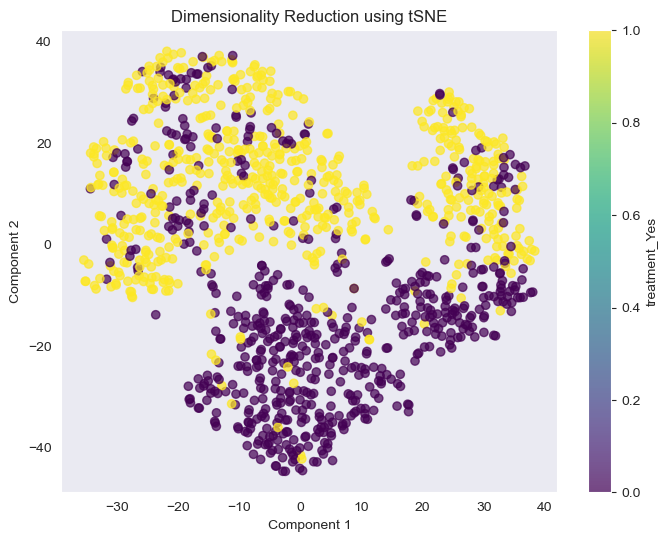

In [106]:
_ = dimensionality_reduction(
    transformed_df.drop(columns = ['Timestamp', 'comments', 'obs_consequence', 'Gender', 'Age', 'Country', 'state',
                                   'Standardized_Gender_Male', 'Standardized_Gender_Other']),
    method = 'tSNE',
    target_column = 'treatment_Yes')

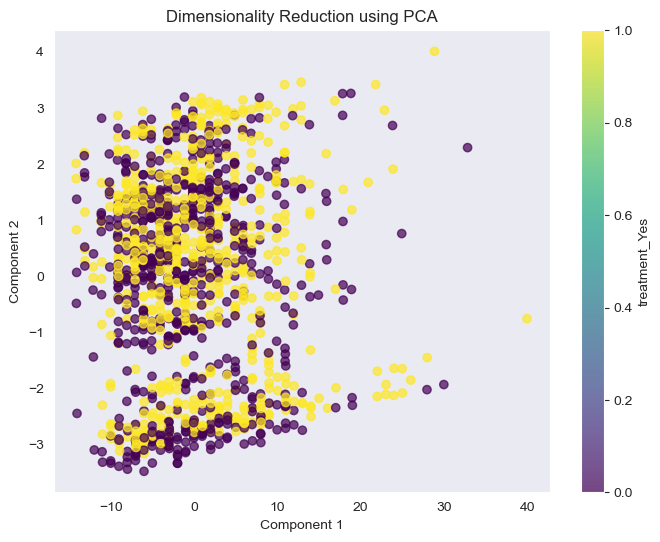

In [89]:
_ = dimensionality_reduction(
    transformed_df.drop(columns = ['Timestamp', 'comments', 'obs_consequence', 'Gender', 'Age', 'Country', 'state']),
    method = 'PCA',
    target_column = 'treatment_Yes')

C:\ProgramData\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



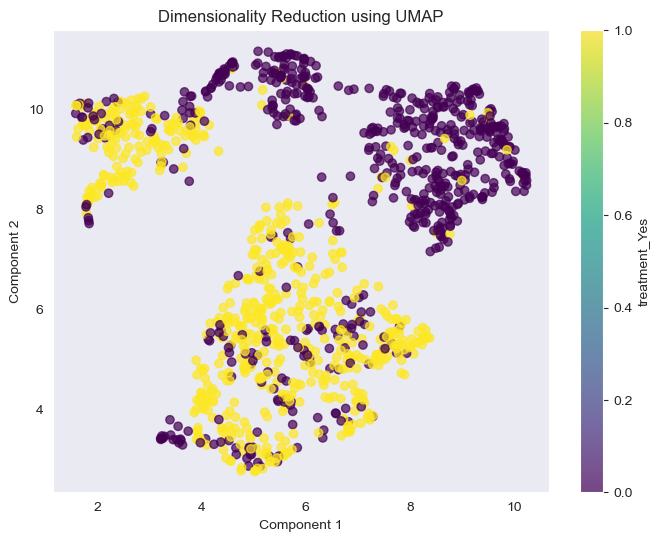

In [105]:
_ = dimensionality_reduction(
    transformed_df.drop(columns = ['Timestamp', 'comments', 'obs_consequence', 'Gender', 'Age', 'Country', 'state']),
    method = 'UMAP',
    target_column = 'treatment_Yes')